<a href="https://colab.research.google.com/github/DeepakSrikanth/Diet-Recommendation-System/blob/main/Brain_MRI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.cuda.is_available()

True

SEtting up colab and linking kaggle for dataset

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"deepaks23mis0406","key":"7e6e5bf2dfd8f5e2750f8e5401b89d57"}'}

In [ ]:
!ls


 brain-tumor-mri-dataset.zip   sample_data  'Unknown (1).jpeg'
 kaggle.json		       Testing	    'Unknown (2).jpeg'
 mri_model.pth		       Training      Unknown.jpeg


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"deepaks23mis0406","key":"7e6e5bf2dfd8f5e2750f8e5401b89d57"}'}

In [ ]:
!ls


 brain-tumor-mri-dataset.zip   mri_model.pth   Training		   Unknown.jpeg
'kaggle (1).json'	       sample_data    'Unknown (1).jpeg'
 kaggle.json		       Testing	      'Unknown (2).jpeg'


In [ ]:
!rm "kaggle (1).json"


In [ ]:
!ls

 brain-tumor-mri-dataset.zip   sample_data  'Unknown (1).jpeg'
 kaggle.json		       Testing	    'Unknown (2).jpeg'
 mri_model.pth		       Training      Unknown.jpeg


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip brain-tumor-mri-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
!ls


 brain-tumor-mri-dataset.zip   Testing		  'Unknown (2).jpeg'
 mri_model.pth		       Training		   Unknown.jpeg
 sample_data		      'Unknown (1).jpeg'


In [ ]:
import os

base_path = "/content/Training"

for folder in os.listdir(base_path):
    print(folder, ":", len(os.listdir(os.path.join(base_path, folder))))


pituitary : 1400
glioma : 1400
meningioma : 1400
notumor : 1400


CNN Modules Download

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


CNN - Image Pre Processing

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

Loading and traning Dataset

In [ ]:
train_dataset = datasets.ImageFolder("/content/Training", transform=transform)
test_dataset = datasets.ImageFolder("/content/Testing", transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


Loading ResNet 34 (transfer Learning )

In [ ]:
model = models.resnet34(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 4)

# Train only last layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Defining Loss and Optimzer


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

Traning Loop (Basic Versions)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 214.9082
Epoch [2/10], Loss: 160.2175
Epoch [3/10], Loss: 133.9751
Epoch [4/10], Loss: 119.0211
Epoch [5/10], Loss: 108.5864
Epoch [6/10], Loss: 100.8541
Epoch [7/10], Loss: 96.2972
Epoch [8/10], Loss: 92.2245
Epoch [9/10], Loss: 89.1790
Epoch [10/10], Loss: 86.3779


In [ ]:
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.00001)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"[Fine-tune] Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

[Fine-tune] Epoch [1/10], Loss: 63.6701
[Fine-tune] Epoch [2/10], Loss: 43.3113
[Fine-tune] Epoch [3/10], Loss: 33.9647
[Fine-tune] Epoch [4/10], Loss: 26.0126
[Fine-tune] Epoch [5/10], Loss: 21.8751
[Fine-tune] Epoch [6/10], Loss: 18.9111
[Fine-tune] Epoch [7/10], Loss: 16.3304
[Fine-tune] Epoch [8/10], Loss: 12.4076
[Fine-tune] Epoch [9/10], Loss: 11.0092
[Fine-tune] Epoch [10/10], Loss: 9.5973


Test Accuracy

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print("Test Accuracy:", test_accuracy, "%")


Test Accuracy: 92.875 %


Save Model

In [ ]:
torch.save(model.state_dict(), "mri_model.pth")

Confusion Matrix

Installing Packages

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

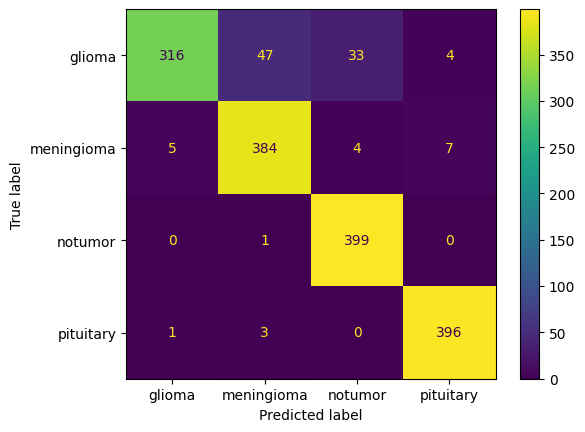

In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.show()

Class Distribution

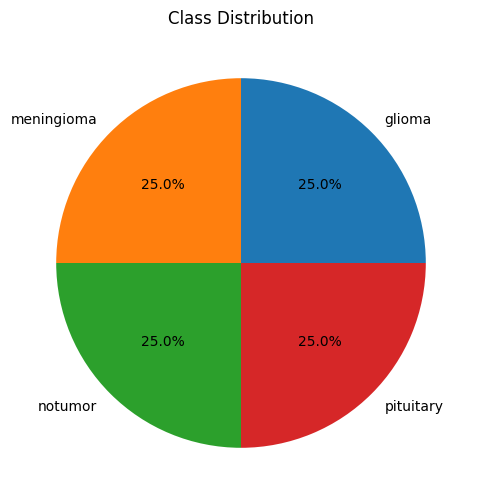

In [ ]:
import matplotlib.pyplot as plt

class_counts = [len(os.listdir(os.path.join(train_dataset.root, cls)))
                for cls in class_names]

plt.figure(figsize=(6,6))
plt.pie(class_counts, labels=class_names, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

Prediction Distribution

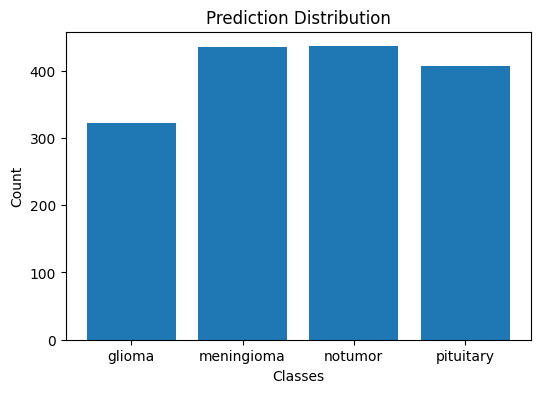

In [ ]:
import numpy as np

unique, counts = np.unique(all_preds, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(class_names, counts)
plt.title("Prediction Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

Class Probablity

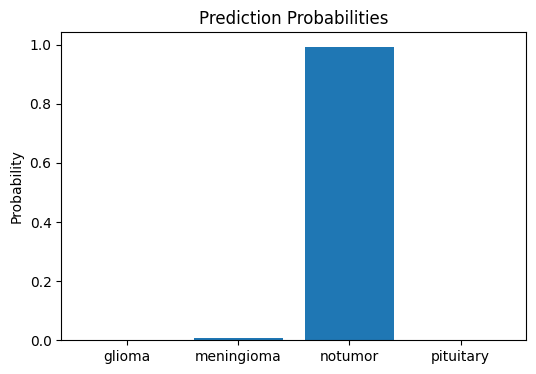

In [ ]:
probs_np = probs.cpu().numpy()[0]

plt.figure(figsize=(6,4))
plt.bar(class_names, probs_np)
plt.title("Prediction Probabilities")
plt.ylabel("Probability")
plt.show()

Report Generator

ADD IMAGE


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Unknown.jpeg to Unknown (4).jpeg


In [ ]:
def edit_report(report, command):
    if "severity" in command:
        return report + "\nSeverity: High"

    elif "remove recommendation" in command:
        return report.replace("Recommendation: Neurological consultation advised.", "")

    elif "rephrase" in command:
        return "Rephrased Report:\n" + report

    else:
        return report

Improved NLP function


In [ ]:
def edit_report(report, command):
    command = command.lower()

    if "severity" in command:
        return report + "\nSeverity: High"

    elif "remove recommendation" in command:
        return report.replace("Recommendation: Neurological consultation advised.", "")

    elif "rephrase" in command:
        return "Rephrased Report:\n" + report

    elif "add location" in command:
        return report + "\nLocation: Frontal lobe region"

    elif "add note" in command:
        return report + "\nNote: Further clinical correlation required."

    else:
        return "No changes applied.\n\n" + report

Testing NLP model

In [ ]:
def generate_report(pred_class):
    if pred_class == "glioma":
        return """Findings: Abnormal lesion detected.
Impression: Suggestive of Glioma.
Recommendation: Neurological consultation advised."""

    elif pred_class == "meningioma":
        return """Findings: Extra-axial mass observed.
Impression: Suggestive of Meningioma."""

    elif pred_class == "pituitary":
        return """Findings: Growth near pituitary region.
Impression: Suggestive of Pituitary tumor."""

    else:
        return """Findings: No abnormality detected.
Impression: MRI appears normal."""

NLP Interactive Editing


In [ ]:
sample_report = generate_report("glioma")

print("Original Report:\n", sample_report)

updated = edit_report(sample_report, "add severity")

print("\nUpdated Report:\n", updated)

Original Report:
 Findings: Abnormal lesion detected.
Impression: Suggestive of Glioma.
Recommendation: Neurological consultation advised.

Updated Report:
 Findings: Abnormal lesion detected.
Impression: Suggestive of Glioma.
Recommendation: Neurological consultation advised.
Severity: High


Prediction Function

In [ ]:
from PIL import Image
import torchvision.transforms as transforms

img_path = list(uploaded.keys())[0]
image = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image_tensor = transform(image).unsqueeze(0).to(device)

In [ ]:
with torch.no_grad():
    outputs = model(image_tensor)

import torch.nn.functional as F

probs = F.softmax(outputs, dim=1)
confidence, pred = torch.max(probs, 1)

In [ ]:
with torch.no_grad():
    outputs = model(image_tensor)

o/p

In [ ]:
class_names = ["Glioma", "Meningioma", "Pituitary Tumor", "No Tumor"]

predicted_class = class_names[pred[0].item()]
conf_score = confidence[0].item() * 100

print("\n AI Brain Tumor Detection Report")
print("----------------------------------------")
print(f"Uploaded Image     : {img_path}")
print(f"Detected Tumor     : {predicted_class}")
print(f"Confidence Score   : {conf_score:.2f}%")
print(f"Model Accuracy     : {test_accuracy:.2f}%")
print("----------------------------------------")


 AI Brain Tumor Detection Report
----------------------------------------
Uploaded Image     : Unknown (4).jpeg
Detected Tumor     : Pituitary Tumor
Confidence Score   : 99.18%
Model Accuracy     : 92.88%
----------------------------------------


Show Image

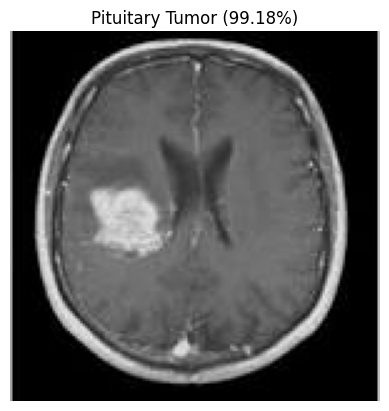

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(f"{predicted_class} ({conf_score:.2f}%)")
plt.axis('off')
plt.show()